# YOLO26 Oriented Bounding Boxes Object Detection with OpenVINO™

[YOLO26-OBB](https://docs.ultralytics.com/tasks/obb/) is the latest Ultralytics model for oriented object detection.

Oriented object detection goes a step further than object detection and introduces an extra angle to locate objects more accurately in an image.

The output of an oriented object detector is a set of rotated bounding boxes that exactly enclose the objects in the image, along with class labels and confidence scores for each box. Object detection is a good choice when you need to identify objects of interest in a scene, but don't need to know exactly where the object is or its exact shape.

[YOLO26](https://docs.ultralytics.com/models/yolo26/) brings several enhancements to OBB:
- **Specialized Angle Loss** — refined OBB decoding with improved angle loss for better rotated box accuracy.
- **End-to-End NMS-Free Inference** — simplified deployment pipeline with lower latency.
- **DFL Removal & Dual-Head Architecture** — streamlined export and broader hardware compatibility.
- **Up to 43% Faster CPU Inference** — optimized for edge computing environments.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Get PyTorch model](#Get-PyTorch-model)
- [Prepare dataset and dataloader](#Prepare-dataset-and-dataloader)
- [Run PyTorch inference](#Run-PyTorch-inference)
- [Convert PyTorch model to OpenVINO IR](#Convert-PyTorch-model-to-OpenVINO-IR)
    - [Select inference device](#Select-inference-device)
    - [Run OpenVINO inference](#Run-OpenVINO-inference)
- [Quantization](#Quantization)
    - [Validate Quantized Model](#Validate-Quantized-Model)
- [Compare inference time and model sizes](#Compare-inference-time-and-model-sizes)

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/yolov26-optimization/yolov26-obb.ipynb" />

### Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [ ]:
import platform


if platform.system() == "Darwin":
    %pip install -q "numpy<2.0.0"


%pip install -qU "openvino>=2026.0.0" "nncf>=3.0.0"
%pip install -q "torch==2.10" torchvision --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "ultralytics==8.4.22" tqdm

Import required utility functions. The lower cell will download the `notebook_utils` Python module from GitHub.

In [2]:
from pathlib import Path
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )

    open("notebook_utils.py", "w").write(r.text)

from notebook_utils import download_file, device_widget, quantization_widget

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("yolov26-obb.ipynb")

### Get PyTorch model
[back to top ⬆️](#Table-of-contents:)

Generally, PyTorch models represent an instance of the [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) class, initialized by a state dictionary with model weights.
We will use the YOLO26 nano OBB model (also known as `yolo26n-obb`) pre-trained on a DOTAv1 dataset, which is available in this [repo](https://github.com/ultralytics/ultralytics). Similar steps are also applicable to other YOLO26 OBB models (`yolo26s-obb`, `yolo26m-obb`, `yolo26l-obb`, `yolo26x-obb`).

In [3]:
import ipywidgets as widgets

model_id = ["yolo26n-obb", "yolo26s-obb", "yolo26m-obb", "yolo26l-obb", "yolo26x-obb"]

model_name = widgets.Dropdown(options=model_id, value="yolo26n-obb", description="Model")

model_name

Dropdown(description='Model', options=('yolo26n-obb', 'yolo26s-obb', 'yolo26m-obb', 'yolo26l-obb', 'yolo26x-ob…

In [ ]:
from ultralytics import YOLO

OBB_MODEL_NAME = model_name.value

model = YOLO(f"{OBB_MODEL_NAME}.pt")
model.to("cpu")

### Prepare dataset and dataloader
[back to top ⬆️](#Table-of-contents:)

YOLO26-OBB is pre-trained on the DOTA dataset. Ultralytics provides the DOTA8 dataset — a small, but versatile oriented object detection dataset composed of the first 8 images of the split DOTAv1 set, 4 for training and 4 for validation. This dataset is ideal for testing and debugging object detection models.

The original model repository uses a Validator wrapper, which represents the accuracy validation pipeline. It creates dataloader and evaluation metrics and updates metrics on each data batch produced by the dataloader.

In [ ]:
from ultralytics.cfg import get_cfg
from ultralytics.data.utils import check_det_dataset
from ultralytics.utils import DEFAULT_CFG, DATASETS_DIR


CFG_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/dota8.yaml"
OUT_DIR = Path("./datasets")
CFG_PATH = OUT_DIR / "dota8.yaml"

if not CFG_PATH.exists():
    download_file(CFG_URL, CFG_PATH.name, CFG_PATH.parent)

args = get_cfg(cfg=DEFAULT_CFG)
args.data = CFG_PATH
args.task = model.task
args.imgsz = 1024

validator = model.task_map[model.task]["validator"](args=args)

validator.stride = 32
validator.data = check_det_dataset(str(args.data))
data_loader = validator.get_dataloader(DATASETS_DIR / "dota8", 1)
example_image_path = list(data_loader)[1]["im_file"][0]

### Run PyTorch inference
[back to top ⬆️](#Table-of-contents:)


image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/datasets/dota8/images/train/P1053__1024__0___90.jpg: 1024x1024 9 tennis courts, 6 small vehicles, 1 swimming pool, 104.0ms
Speed: 5.5ms preprocess, 104.0ms inference, 0.2ms postprocess per image at shape (1, 3, 1024, 1024)


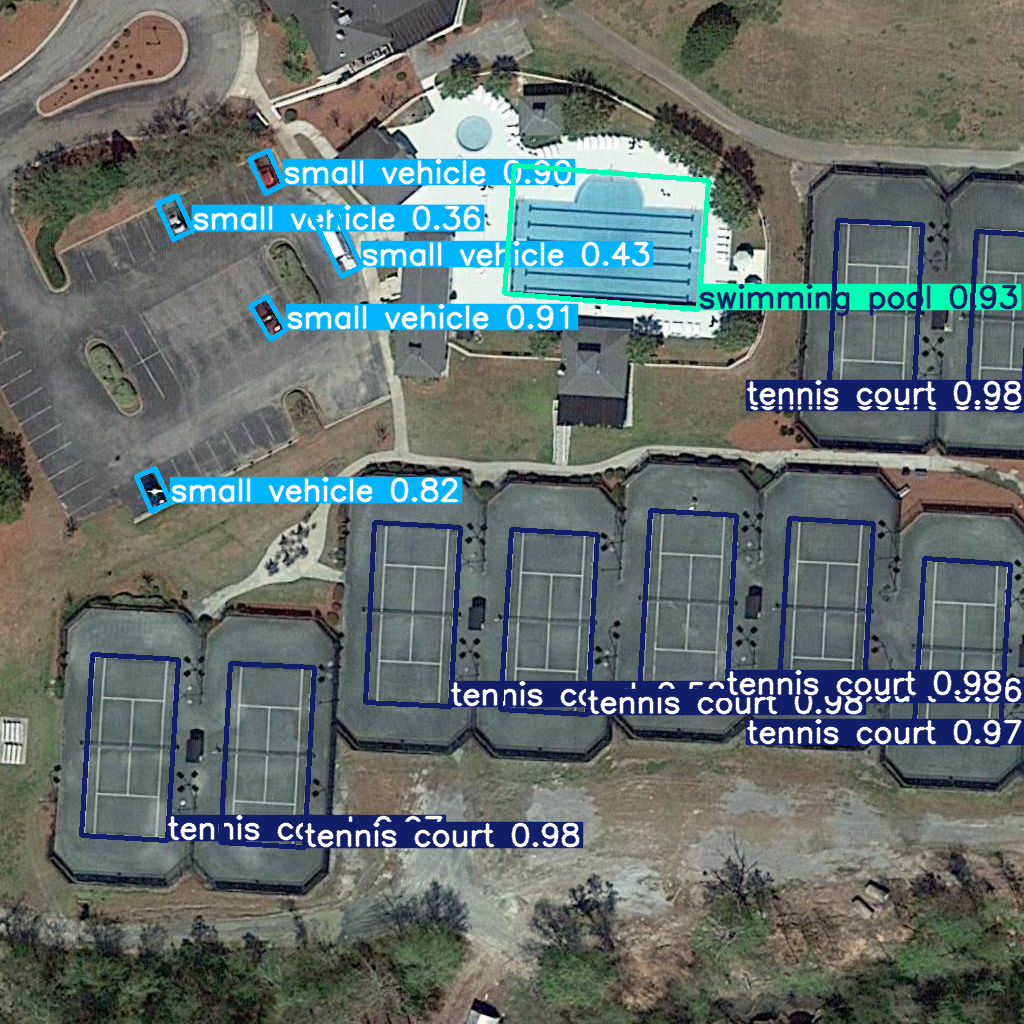

In [6]:
from PIL import Image

res = model(example_image_path, device="cpu")
Image.fromarray(res[0].plot()[:, :, ::-1])

### Convert PyTorch model to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

Ultralytics provides the `model.export()` method for converting models to OpenVINO IR format. Key parameters for YOLO26:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `format` | `"openvino"` | Target export format |
| `half` | `True` | Export weights in FP16 precision for smaller model size and faster inference |
| `dynamic` | `True` / `False` | `dynamic=True` preserves the original preprocessing behavior (adaptive LetterBox padding) and produces results closest to the PyTorch model. `dynamic=False` uses fixed 640×640 input shape — required for NPU deployment and may improve throughput, but can slightly affect detection results due to different padding |
| `end2end` | `True` | **Required for YOLO26.** Exports NMS-free end-to-end model. YOLO26 uses a single one2one detection head, so `end2end=False` will cause a `KeyError` at export |

> **Note**: Unlike older YOLO versions (v8, v11) that support both `end2end=True` and `end2end=False`, YOLO26 is architecturally NMS-free and only works with `end2end=True`.

In [7]:
OV_MODEL_PATH = Path(f"{OBB_MODEL_NAME}_openvino_model/{OBB_MODEL_NAME}.xml")
if not OV_MODEL_PATH.exists():
    model.export(format="openvino", dynamic=False, half=True, end2end=True)

#### Select inference device
[back to top ⬆️](#Table-of-contents:)

Select device from dropdown list for running inference using OpenVINO

In [8]:
device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

#### Run OpenVINO inference
[back to top ⬆️](#Table-of-contents:)

We can reuse the base model pipeline specifying Intel devices (intel:gpu, intel:npu, intel:cpu) when running inference with OpenVINO.

Loading yolo26n-obb_openvino_model for OpenVINO inference...
WARNING ⚠️ OpenVINO device 'AUTO' not available. Using 'AUTO' instead.
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/datasets/dota8/images/train/P1053__1024__0___90.jpg: 1024x1024 9 tennis courts, 6 small vehicles, 1 swimming pool, 30.4ms
Speed: 5.5ms preprocess, 30.4ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)


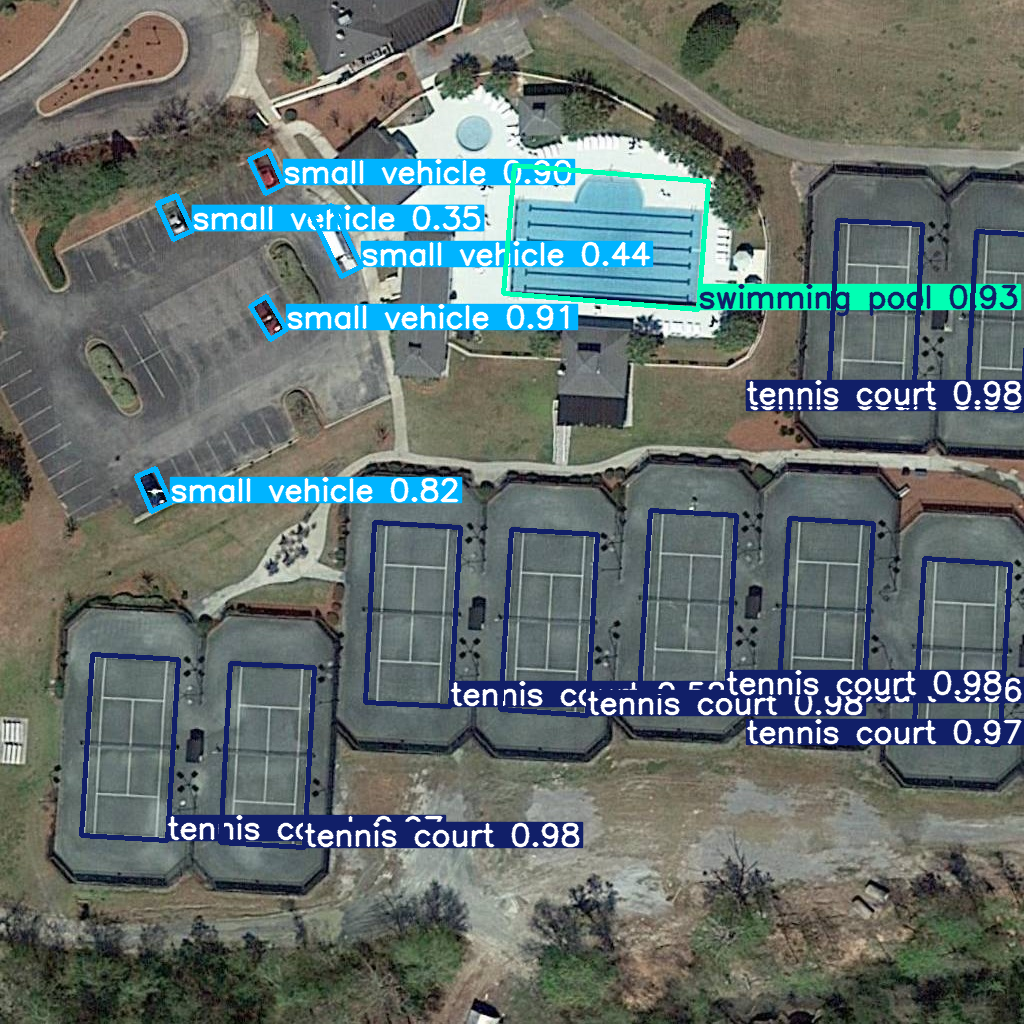

In [9]:
ov_obb_model = YOLO(OV_MODEL_PATH.parent, task="obb")

res = ov_obb_model(example_image_path, device=f"intel:{device.value.lower()}")
Image.fromarray(res[0].plot()[:, :, ::-1])

### Quantization
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf/) enables post-training quantization by adding quantization layers into model graph and then using a subset of the training dataset to initialize the parameters of these additional quantization layers. Quantized operations are executed in `INT8` instead of `FP32`/`FP16` making model inference faster.

The optimization process contains the following steps:

1. Create a calibration dataset for quantization.
2. Run `nncf.quantize()` to obtain quantized model.
3. Save the `INT8` model using `openvino.save_model()` function.

Please select below whether you would like to run quantization to improve model inference speed.

In [10]:
INT8_OV_PATH = Path(f"{OBB_MODEL_NAME}_openvino_model_int8/{OBB_MODEL_NAME}.xml")

to_quantize = quantization_widget()

to_quantize

Checkbox(value=True, description='Quantization')

Let's load `skip magic` extension to skip quantization if `to_quantize` is not selected

In [11]:
# Fetch skip_kernel_extension module
if not Path("skip_kernel_extension.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
    )
    open("skip_kernel_extension.py", "w").write(r.text)

%load_ext skip_kernel_extension

In [12]:
%%skip not $to_quantize.value

import nncf
import torch


if validator.device is None:
    validator.device = torch.device("cpu")


def transform_fn(data_item: dict):
    input_tensor = validator.preprocess(data_item)["img"].numpy()
    return input_tensor


quantization_dataset = nncf.Dataset(data_loader, transform_fn)

Create a quantized model from the pre-trained converted OpenVINO model.

> **NOTE**: Quantization is time and memory consuming operation. Running quantization code below may take some time.

> **NOTE**: We use the tiny DOTA8 dataset as a calibration dataset. It gives a good enough result for tutorial purpose. For better results, use a bigger dataset. Usually 300 examples are enough.

The `nncf.quantize` function provides an interface for model quantization. It requires an instance of the OpenVINO Model and quantization dataset.
Optionally, some additional parameters for the configuration quantization process (number of samples for quantization, preset, ignored scope, etc.) can be provided. Ultralytics models contain non-ReLU activation functions, which require asymmetric quantization of activations. To achieve a better result, we will use a `mixed` quantization preset. It provides symmetric quantization of weights and asymmetric quantization of activations.

Following the [NNCF optimal settings for YOLO26](https://github.com/openvinotoolkit/nncf/tree/develop/examples/post_training_quantization/openvino/yolo26), we also disable `fast_bias_correction` and add the `.*one2one.*` pattern to `ignored_scope` to prevent accuracy degradation in the NMS-free detection head.

>**Note**: Model post-training quantization is a time-consuming process. Be patient, it can take several minutes depending on your hardware.

In [ ]:
%%skip not $to_quantize.value

import shutil
import openvino as ov

core = ov.Core()

if not INT8_OV_PATH.exists():
    ov_model = core.read_model(OV_MODEL_PATH)
    quantized_model = nncf.quantize(
        ov_model,
        quantization_dataset,
        preset=nncf.QuantizationPreset.MIXED,
        fast_bias_correction=False,
        ignored_scope=nncf.IgnoredScope(patterns=[".*one2one.*"])
    )
    ov.save_model(quantized_model, INT8_OV_PATH)
    shutil.copy(OV_MODEL_PATH.parent / "metadata.yaml", INT8_OV_PATH.parent / "metadata.yaml")

### Validate Quantized Model
[back to top ⬆️](#Table-of-contents:)

Let's verify the quantized model produces correct results on the test image.

Loading yolo26n-obb_openvino_model_int8 for OpenVINO inference...
WARNING ⚠️ OpenVINO device 'AUTO' not available. Using 'AUTO' instead.
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/datasets/dota8/images/train/P1053__1024__0___90.jpg: 1024x1024 9 tennis courts, 5 small vehicles, 1 swimming pool, 25.7ms
Speed: 11.0ms preprocess, 25.7ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)


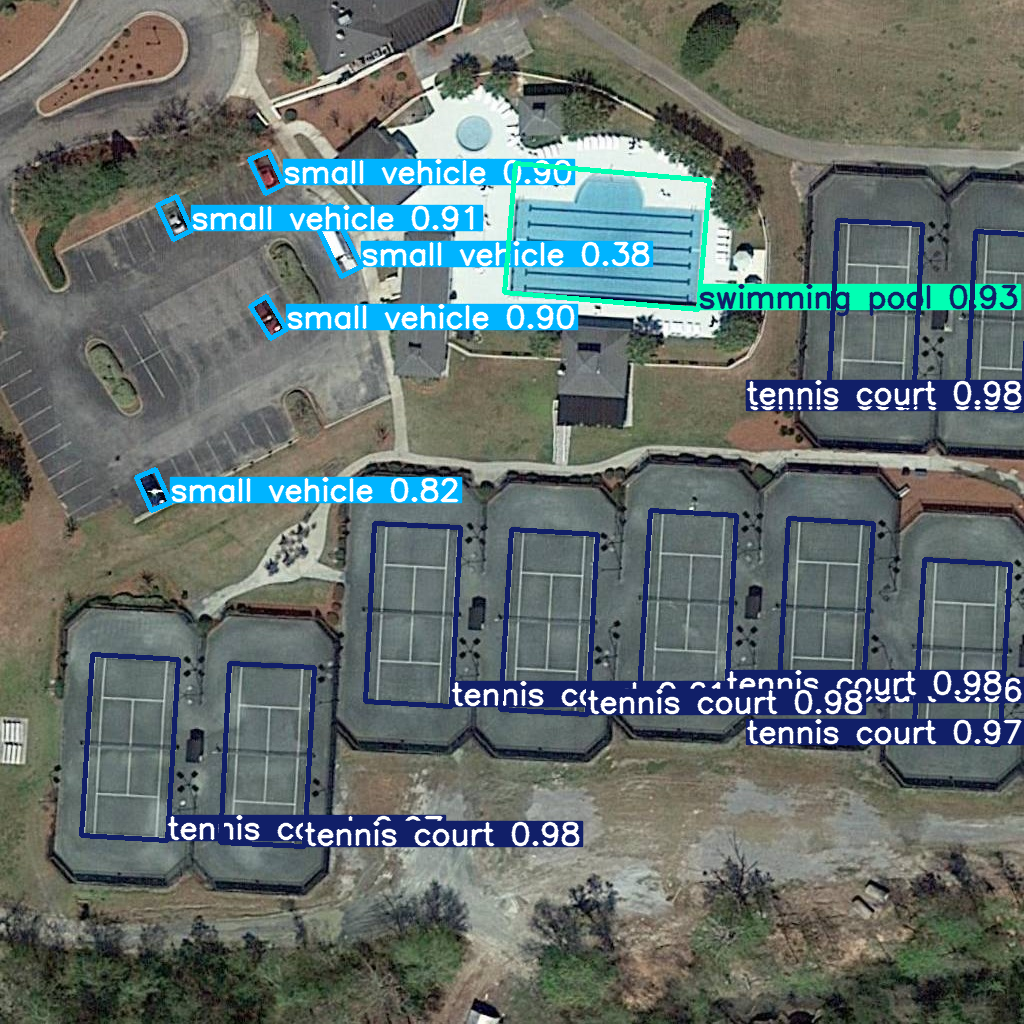

In [14]:
%%skip not $to_quantize.value

int8_obb_model = YOLO(INT8_OV_PATH.parent, task="obb")

res = int8_obb_model(example_image_path, device=f"intel:{device.value.lower()}")
display(Image.fromarray(res[0].plot()[:, :, ::-1]))

### Compare inference time and model sizes
[back to top ⬆️](#Table-of-contents:)

In [15]:
%%skip not $to_quantize.value

fp16_ir_model_size = OV_MODEL_PATH.with_suffix(".bin").stat().st_size / 1024
quantized_model_size = INT8_OV_PATH.with_suffix(".bin").stat().st_size / 1024

print(f"FP16 model size: {fp16_ir_model_size:.2f} KB")
print(f"INT8 model size: {quantized_model_size:.2f} KB")
print(f"Model compression rate: {fp16_ir_model_size / quantized_model_size:.3f}")

FP16 model size: 4910.29 KB
INT8 model size: 2743.73 KB
Model compression rate: 1.790


In [16]:
# Inference FP16 model (OpenVINO IR)
!benchmark_app -m $OV_MODEL_PATH -d $device.value -api async -shape "[1,3,1024,1024]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line or config file. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 26.66 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [1,3,1024,1024]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.model.23/aten::cat/Concat_6) : f32 / [...] / [1,300,7]
[Step 5/11] Resizing model to match image sizes and given batch
[ IN

In [17]:
if INT8_OV_PATH.exists():
    # Inference INT8 model (Quantized model)
    !benchmark_app -m $INT8_OV_PATH -d $device.value -api async -shape "[1,3,1024,1024]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line or config file. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 27.83 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [1,3,1024,1024]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.model.23/aten::cat/Concat_6) : f32 / [...] / [1,300,7]
[Step 5/11] Resizing model to match image sizes and given batch
[ IN